### Vector potential of current carrying winding



Failure to parse tags from meshio.


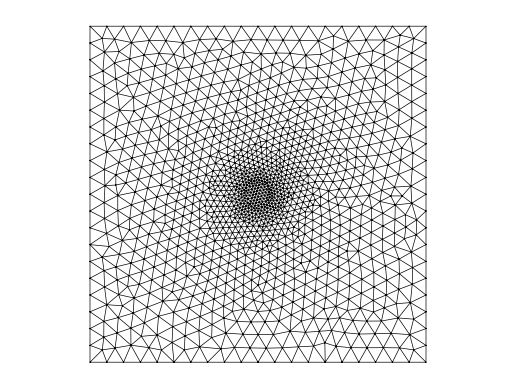

In [3]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/wire.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

Get triangular elements and first order basis functions. We need to define own basis for 'air' and 'wire' domains, because the J=0 in air and J = Jz at wire. 

In [44]:
e = ElementTriP1()
basis = Basis(mesh, e)
basis_wire = basis.with_elements(mesh.subdomains["wire"])
basis_air = basis.with_elements(mesh.subdomains["air"])


print(basis_wire)
print(basis_air)
print(basis)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 1271
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2248
  Number of DOFs: 1271
  Size: 485568 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2460
  Number of DOFs: 1271
  Size: 531360 B


Bilinear and linear forms, from weak formulation


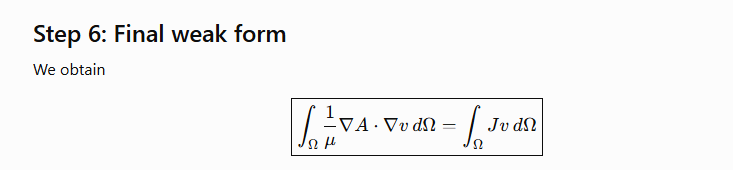

Assemble the system

In [45]:
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

wire_area = area.assemble(basis_wire)

print("Win area: ", wire_area)

@BilinearForm
def laplace(A, v, _):
    mu0 = 4*np.pi*1e-7
    return 1/mu0*dot(grad(A), grad(v))


@LinearForm
def rhs_wire(v, _):
    I_z = 100
    r = 0.05
    A = np.pi*r**2
    J_z = I_z/A
    return J_z * v

@LinearForm
def rhs_air(v, _):
    return 0 * v


S_mat = laplace.assemble(basis)
b = rhs_wire.assemble(basis_wire)
b = b + rhs_air.assemble(basis_air)




Win area:  0.007803612880645133


Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [46]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())   


Solve & Visualize Az = vecotr pootential

[4.71522964e-05 0.00000000e+00 0.00000000e+00 ... 5.22946724e-05
 5.17445841e-05 5.18758640e-05]


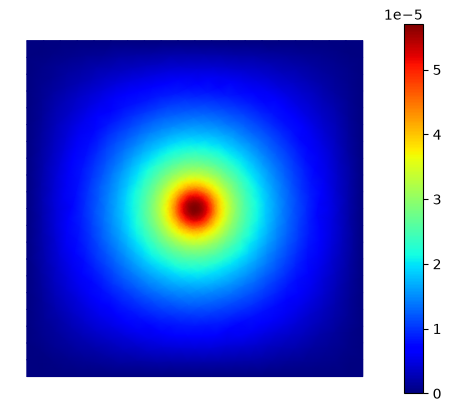

In [47]:
A_z = solve(S_mat, b)

print(A_z)

def visualize():
    from skfem.visuals.matplotlib import plot
    return plot(mesh, A_z, shading='gouraud', colorbar=True)

if __name__ == "__main__":
    visualize().show()

Now we compute Bx and By with partial derivatives to plot B field

(2, 1271)
(3, 2460)
(2, 3, 2460)
(2, 2460)


Text(0.5, 1.0, 'B-field around wire')

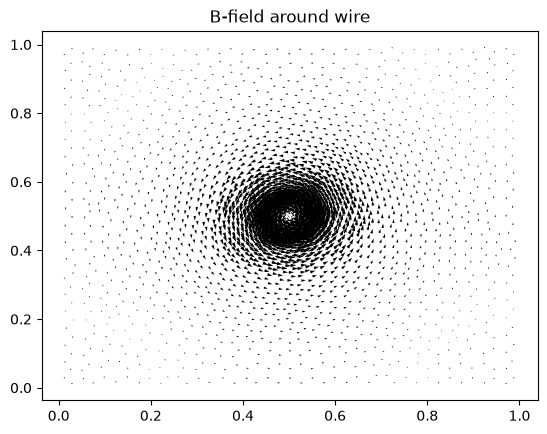

In [48]:
# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

centers = mesh.p[:, mesh.t].mean(axis=2)

print(mesh.p.shape)
print(mesh.t.shape)

print(mesh.p[:, mesh.t].shape)
centers = mesh.p[:, mesh.t].mean(axis=1)
print(centers.shape)

plt.quiver(
    centers[0],
    centers[1],
    Bx_elem,
    By_elem
)

plt.title("B-field around wire")



The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.


In [49]:
# Build connectivity. This help to find elements that share nodes. Then we know which gradient values to average for specific node.
node_to_elements = [[] for _ in range(mesh.nvertices)]

for elem in range(mesh.nelements):

    for node in mesh.t[:, elem]:

        node_to_elements[node].append(elem)


Bx_node = np.zeros(mesh.nvertices)
By_node = np.zeros(mesh.nvertices)



for node in range(mesh.nvertices):
    # all elements that share 'node'
    elems = node_to_elements[node]

    # nodal averaged values for Bx and By
    Bx_node[node] = np.mean(Bx_elem[elems])
    By_node[node] = np.mean(By_elem[elems])

B_norm = np.sqrt(Bx_node**2+By_node**2)

print(Bx_node.shape)
print(B_norm.shape)


(1271,)
(1271,)


Compute B-norm and plot



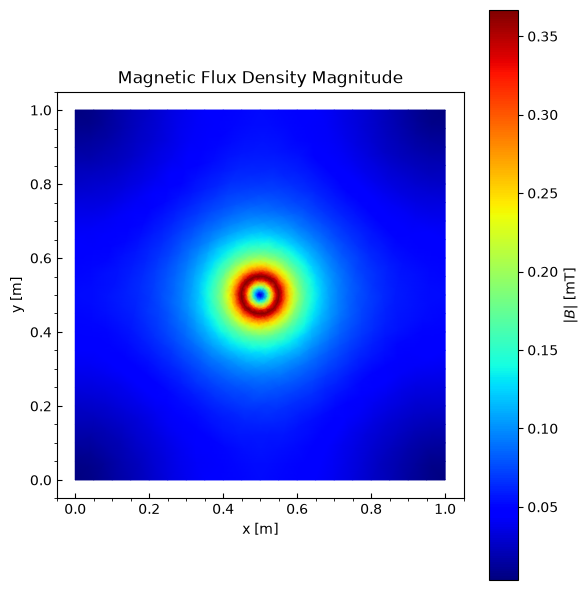

In [50]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
def visualize():
    fig, ax = plt.subplots(figsize=(6, 6))

    plot(
        mesh,
        1000 * B_norm,
        ax=ax,              # <-- important
        shading='gouraud',
        colorbar=True
    )

    ax.set_title("Magnetic Flux Density Magnitude")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

    ax.tick_params(direction='in')
    ax.minorticks_on()

    # Colorbar is a second axes in the figure
    cbar = fig.axes[-1]
    cbar.set_ylabel(r"$|B|$ [mT]")

    fig.tight_layout()

if __name__ == "__main__":
    visualize()
    plt.show()

Lets evalueate the Bnorm at coordinate (0.7, 0.8). Then we compare this with analytical Biot-Savart law


In [51]:
x = 0.7
y = 0.8

points = np.array([[x],
                   [y]])

# Create interpolation matrix
P = basis.probes(points)

# Interpolate the nodal fields
Bx = (P @ Bx_node)[0]
By = (P @ By_node)[0]

# same than sqrt(Bx^2+By^2)
Bnorm_point = np.hypot(Bx, By)

print(f"Bnorm at point ({x}, {y}) = {1000*Bnorm_point} mT")



Bnorm at point (0.7, 0.8) = 0.05229984596286898 mT


Lets compare this to analytical Biot-Savart law.


In [42]:
r = np.sqrt((x-0.5)**2+(y-0.5)**2)

mu0 = 4*np.pi*1e-7
I = 100
B_biotsavart = mu0*I/(2*np.pi*r)

print(f"Analytical Bnorm at point ({x}, {y}) = {1000*B_biotsavart} mT")

Analytical Bnorm at point (0.7, 0.8) = 0.05547001962252291 mT


Our solutions differs 0.046752 mT,  so it is capturing the phenomena with okay accuracy even with 1270 DOFs